# `CEModel` Quickstart

This notebook is the fastest path to understanding the generalized Conditional
Embedding (CE) model package: `conditional_embedding_model.general`. It builds a
`CEModel` purely from a config, trains it on synthetic paired data with a known
ground-truth affinity structure, and checks that the learned affinity matrix
actually recovers that structure.

No PyBullet, no `CoopGrasping-v6_dataset.pkl`, no GPU required — everything here
runs on CPU in well under a minute.

Design background and the full rationale for this API live in
`plans/ce-model-generalization/PLAN.md` and `general/README.md`.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from conditional_embedding_model.general import (
    CEModelConfig, EncoderConfig, ScorerConfig, build_model, ContrastiveBCELoss, Trainer,
)
from conditional_embedding_model.general.examples.toy import make_toy_data

torch.manual_seed(0)
np.random.seed(0)


## 1. What a `CEModel` config specifies

A `CEModel` is composition, not inheritance: a **center encoder**, a **context
encoder**, and a **scorer**, wired together by `build_model(config)`. The config is
three small dataclasses:

- `EncoderConfig(name, params)` — `name` is a string key into a registry
  (`ENCODER_REGISTRY`); `params` are the kwargs passed to that encoder's
  constructor. Swapping architectures is a one-line config edit, not a subclass.
- `ScorerConfig(name, params)` — same idea for the similarity function that turns
  a pair of embeddings into an affinity score.
- `CEModelConfig(embedding_dim, center_encoder, context_encoder, scorer)` — the
  top-level config `build_model` consumes.

Here we use the built-in `"mlp"` encoder (`MLPEncoder`) for both towers — a plain
feed-forward net over a single flat feature key — and the built-in
`"cosine_temperature"` scorer, which reproduces the paper's original
temperature-scaled cosine similarity.

In [2]:
obs_dim, K, latent_dim, n_pos, embedding_dim = 32, 16, 4, 2, 8

encoder_params = dict(
    input_dim=obs_dim, output_dim=embedding_dim,
    hidden_dims=(64, 64), activation="relu", layer_norm=True,
)
config = CEModelConfig(
    embedding_dim=embedding_dim,
    center_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    context_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    scorer=ScorerConfig(name="cosine_temperature", params={"temperature": 0.07}),
)
model = build_model(config)
model


CEModel(
  (center_encoder): MLPEncoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=8, bias=True)
    )
  )
  (context_encoder): MLPEncoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=8, bias=True)
    )
  )
  (scorer): CosineTemperatureScorer()
)

## 2. Synthetic data with a known ground-truth affinity

We reuse `make_toy_data` from the toy example (Task 04,
`general/examples/toy.py`) rather than writing a new generator. It plants a
rank-`latent_dim` affinity `a[i, j] = ẑ_c[i] · ẑ_x[i, j]` between L2-normalized
latent vectors, then only exposes noisy linear *observations* of those latents
(`center_x`, `context_x`) to the model — the model never sees `z_c`/`z_x`
directly, only the 32-dimensional projections. Labels mark the top-`n_pos`
candidates per center by true affinity, and a random mask zeros out 0-3 trailing
candidate slots per row to exercise the padding path used everywhere in the real
pipeline.

In [3]:
train_data, val_data, W = make_toy_data(
    n_centers=4096, K=K, latent_dim=latent_dim, obs_dim=obs_dim,
    noise=0.1, n_pos=n_pos, seed=0,
)
print({k: tuple(v.shape) for k, v in train_data.items()})


{'center_x': (3277, 32), 'context_x': (3277, 16, 32), 'label': (3277, 16), 'mask': (3277, 16)}


In [4]:
from torch.utils.data import DataLoader, Dataset as TorchDataset


class _ToyDataset(TorchDataset):
    def __init__(self, data):
        self.center_x = data["center_x"]
        self.context_x = data["context_x"]
        self.label = data["label"]
        self.mask = data["mask"]

    def __len__(self):
        return self.center_x.shape[0]

    def __getitem__(self, i):
        return self.center_x[i], self.context_x[i], self.label[i], self.mask[i]


def _collate(batch):
    center_x = torch.stack([b[0] for b in batch])
    context_x = torch.stack([b[1] for b in batch])
    label = torch.stack([b[2] for b in batch])
    mask = torch.stack([b[3] for b in batch])
    # dict-of-tensors is the CEModel input contract: each encoder pulls the
    # keys it declared in its `input_spec` (here, the MLPEncoder's "x").
    return ({"x": center_x}, {"x": context_x}), label, mask


train_loader = DataLoader(_ToyDataset(train_data), batch_size=256, shuffle=True, collate_fn=_collate)
val_loader = DataLoader(_ToyDataset(val_data), batch_size=256, shuffle=False, collate_fn=_collate)


## 3. What `forward()` returns

`CEModel.forward(center_inputs, context_inputs)` embeds the center batch to
`[B, E]`, embeds the context batch to `[B, K, E]`, and scores them into `[B, K]`
— one affinity logit per (center, candidate) pair, matching the shape of `label`
and `mask` exactly. Let's confirm that shape contract on one batch before
training anything.

In [5]:
(center_inputs, context_inputs), label, mask = next(iter(train_loader))
with torch.no_grad():
    logits = model(center_inputs, context_inputs)
print("center_inputs['x']:", tuple(center_inputs["x"].shape))
print("context_inputs['x']:", tuple(context_inputs["x"].shape))
print("logits (forward output):", tuple(logits.shape))
print("label / mask:", tuple(label.shape), tuple(mask.shape))
assert logits.shape == label.shape == mask.shape


center_inputs['x']: (256, 32)
context_inputs['x']: (256, 16, 32)
logits (forward output): (256, 16)
label / mask: (256, 16) (256, 16)


## 4. Training loop

`ContrastiveBCELoss` is a masked, dynamically-weighted binary cross-entropy over
the `[B, K]` logits (padding slots contribute zero via `mask`). `Trainer.fit`
runs the standard loop: forward → loss → backward → optimizer step per batch,
with an optional scheduler and validation pass per epoch. We train for a modest
number of epochs — enough for the loss to visibly drop and the affinity matrix
to visibly sharpen, without turning this quickstart into a long-running
benchmark.

In [6]:
loss_fn = ContrastiveBCELoss(normalization="valid_pairs")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, loss_fn, optimizer, device="cpu", amp=False)

history = trainer.fit(train_loader, val_loader=val_loader, epochs=15)
print("first epoch train loss:", history["train_loss"][0])
print("final epoch train loss:", history["train_loss"][-1])


first epoch train loss: 0.26651904356432204
final epoch train loss: 0.05528580059131136


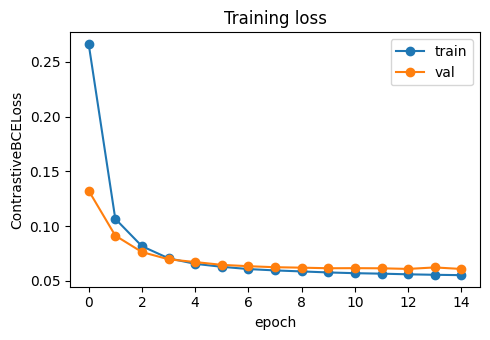

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(history["train_loss"], marker="o", label="train")
ax.plot(history["val_loss"], marker="o", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("ContrastiveBCELoss")
ax.set_title("Training loss")
ax.legend()
fig.tight_layout()


## 5. Learned vs. ground-truth affinity

`score_all_pairs(center_inputs, context_inputs)` scores a full center-bank ×
candidate-bank matrix (`[B, M]`, no padding) — the deployment-style retrieval
path. We build a small held-out bank of centers and candidates with known
latents (the same construction `run_toy` uses for its Spearman-correlation
check), compute the true planted affinity directly from those latents, and
compare it side-by-side with what the trained model recovers from the noisy
observations alone.

In [8]:
bank_rng = np.random.default_rng(999)
n_bank = 48
z_c_bank = bank_rng.normal(size=(n_bank, latent_dim))
z_c_bank = z_c_bank / np.linalg.norm(z_c_bank, axis=1, keepdims=True)
z_x_bank = bank_rng.normal(size=(n_bank, latent_dim))
z_x_bank = z_x_bank / np.linalg.norm(z_x_bank, axis=1, keepdims=True)
true_affinity = z_c_bank @ z_x_bank.T

center_bank_obs = z_c_bank @ W.T + 0.1 * bank_rng.normal(size=(n_bank, obs_dim))
context_bank_obs = z_x_bank @ W.T + 0.1 * bank_rng.normal(size=(n_bank, obs_dim))

model.eval()
with torch.no_grad():
    v_inputs = {"x": torch.tensor(center_bank_obs, dtype=torch.float32)}
    u_inputs = {"x": torch.tensor(context_bank_obs, dtype=torch.float32)}
    learned_affinity = model.score_all_pairs(v_inputs, u_inputs).numpy()

from scipy.stats import spearmanr
corr, _ = spearmanr(learned_affinity.flatten(), true_affinity.flatten())
print(f"Spearman correlation (learned vs. ground truth): {corr:.3f}")


Spearman correlation (learned vs. ground truth): 0.979


Learned affinity structure visibly approaches ground truth (Spearman > 0.5).


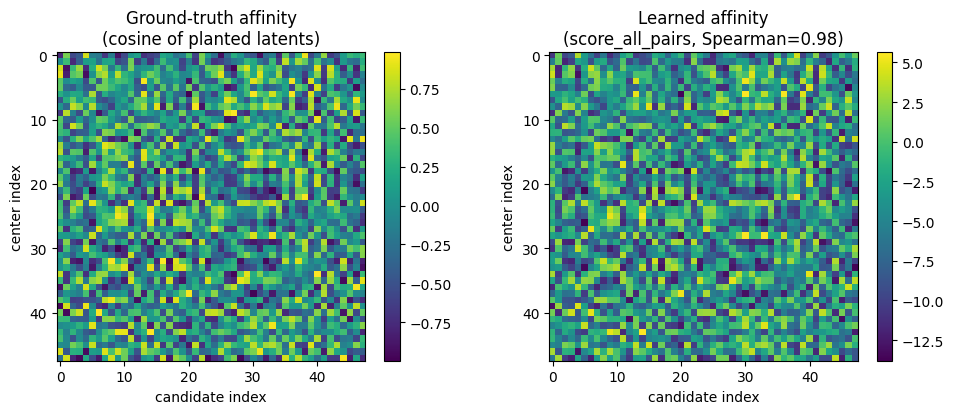

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axes[0].imshow(true_affinity, cmap="viridis")
axes[0].set_title("Ground-truth affinity\n(cosine of planted latents)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(learned_affinity, cmap="viridis")
axes[1].set_title(f"Learned affinity\n(score_all_pairs, Spearman={corr:.2f})")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xlabel("candidate index")
    ax.set_ylabel("center index")
fig.tight_layout()

assert corr > 0.5, f"expected learned affinity to correlate with ground truth, got {corr}"
print("Learned affinity structure visibly approaches ground truth (Spearman > 0.5).")


## Summary

- A `CEModel` is built from a `CEModelConfig` (encoder + encoder + scorer),
  resolved through string registries — no subclassing.
- `forward()` returns `[B, K]` logits matching the shape of `label`/`mask`;
  `score_all_pairs()` returns `[B, M]` for full-bank retrieval.
- `Trainer.fit` handles the standard train/val loop given any `CEModel` +
  loss + optimizer.
- Even a short training run on this synthetic planted-affinity task recovers
  the ground-truth structure, visible both in the loss curve and in the
  learned-vs-true affinity heatmaps.

Next: `NN_custom_architectures.ipynb` shows how to plug in your *own* encoder
and scoring function through the same config-only interface.